<a href="https://colab.research.google.com/github/cysorianoc/IBM_Machine_Learning/blob/main/Course_1_ML_NB_4_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Foundation

## Section 1, Part c: EDA Lab


## Introduction

We will be using the iris data set for this tutorial. This is a well-known data set containing iris species and sepal and petal measurements. The data we will use are in a file called `iris_data.csv` found in the [data](data/) directory.


In [18]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [19]:
import os
import numpy as np
import pandas as pd

## Question 1

Load the data from the file using the techniques learned today. Examine it.

Determine the following:

* The number of data points (rows). (*Hint:* check out the dataframe `.shape` attribute.)
* The column names. (*Hint:* check out the dataframe `.columns` attribute.)
* The data types for each column. (*Hint:* check out the dataframe `.dtypes` attribute.)


In [20]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0232EN-SkillsNetwork/asset/iris_data.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [21]:
# Determine the number of data points
print('Number of rows',data.shape[0])

# Determine the number of columns
print('Number of columns',data.shape[1])

# Determine the data types of each column
print(data.dtypes)

Number of rows 150
Number of columns 5
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


In [22]:
print('Column Names',list(data.columns))

Column Names ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


## Question 2

Examine the species names and note that they all begin with 'Iris-'. Remove this portion of the name so the species name is shorter.

*Hint:* there are multiple ways to do this, but you could use either the [string processing methods](http://pandas.pydata.org/pandas-docs/stable/text.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) or the [apply method](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.Series.apply.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).


In [23]:
# Examine the species names
data.species.unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [24]:
data['species'] = data.species.str.replace('Iris-', '')

In [25]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Question 3

Determine the following:  
* The number of each species present. (*Hint:* check out the series `.value_counts` method.)
* The mean, median, and quantiles and ranges (max-min) for each petal and sepal measurement.

*Hint:* for the last question, the `.describe` method does have median, but it's not called median. It's the *50%* quantile. `.describe` does not have range though, and in order to get the range, you will need to create a new entry in the `.describe` table, which is `max - min`.


In [ ]:
# Check the number of species
data.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [27]:
# Mean, median and quantiles for each petal and sepal
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [35]:
stats_df=data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

output_df=stats_df.loc[['mean','25%','50%','75%', 'range']]
output_df.rename({'50%': 'median'}, inplace=True)
output_df


,sepal_length,sepal_width,petal_length,petal_width
mean,5.843333,3.054,3.758667,1.198667
25%,5.100000,2.800,1.600000,0.300000
median,5.800000,3.000,4.350000,1.300000
75%,6.400000,3.300,5.100000,1.800000
range,3.600000,2.400,5.900000,2.400000


In [ ]:
### BEGIN SOLUTION
# One way to count each species
data.species.value_counts()

In [ ]:
# Select just the rows desired from the 'describe' method and add in the 'median'
stats_df = data.describe()
stats_df = data.describe()
stats_df.loc['range'] = stats_df.loc['max'] - stats_df.loc['min']

out_fields = ['mean','25%','50%','75%', 'range']
stats_df = stats_df.loc[out_fields]
stats_df.rename({'50%': 'median'}, inplace=True)
stats_df
### END SOLUTION

## Question 4

Calculate the following **for each species** in a separate dataframe:

* The mean of each measurement (sepal_length, sepal_width, petal_length, and petal_width).
* The median of each of these measurements.

*Hint:* you may want to use Pandas [`groupby` method](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.groupby.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) to group by species before calculating the statistic.

If you finish both of these, try calculating both statistics (mean and median) in a single table (i.e. with a single groupby call). See the section of the Pandas documentation on [applying multiple functions at once](http://pandas.pydata.org/pandas-docs/stable/groupby.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01#applying-multiple-functions-at-once) for a hint.


In [36]:
data.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


In [37]:
data.groupby('species').median()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.0,3.4,1.50,0.2
versicolor,5.9,2.8,4.35,1.3
virginica,6.5,3.0,5.55,2.0


In [ ]:
### BEGIN SOLUTION
# The mean calculation
data.groupby('species').mean()

In [ ]:
# The median calculation
data.groupby('species').median()

In [ ]:
# applying multiple functions at once - 2 methods

data.groupby('species').agg(['mean', 'median'])  # passing a list of recognized strings
data.groupby('species').agg([np.mean, np.median])  # passing a list of explicit aggregation functions

In [ ]:
# If certain fields need to be aggregated differently, we can do:
from pprint import pprint

agg_dict = {field: ['mean', 'median'] for field in data.columns if field != 'species'}
agg_dict['petal_length'] = 'max'
pprint(agg_dict)
data.groupby('species').agg(agg_dict)
### END SOLUTION

## Question 5

Make a scatter plot of `sepal_length` vs `sepal_width` using Matplotlib. Label the axes and give the plot a title.


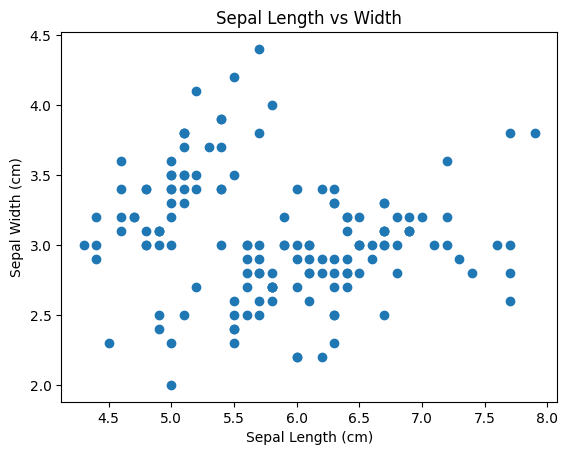

In [38]:
# import the required libraries
import matplotlib.pyplot as plt
%matplotlib inline

plt.scatter(data.sepal_length, data.sepal_width)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Width');

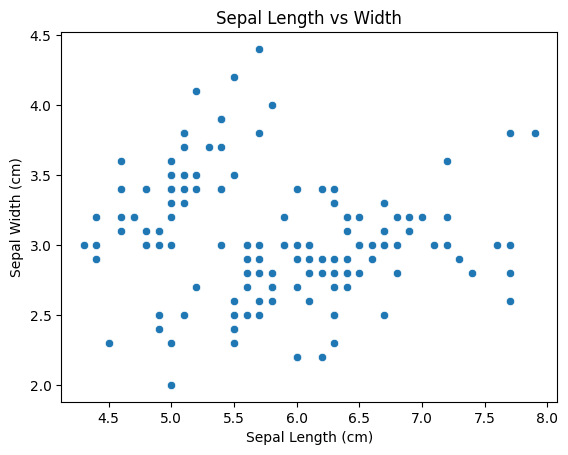

In [42]:
# Also using seaborn
import seaborn as sns
sns.scatterplot(data=data, x='sepal_length', y='sepal_width');
plt.title('Sepal Length vs Width');
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)');

In [ ]:
### BEGIN SOLUTION
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# A simple scatter plot with Matplotlib
ax = plt.axes()

ax.scatter(data.sepal_length, data.sepal_width)

# Label the axes
ax.set(xlabel='Sepal Length (cm)',
       ylabel='Sepal Width (cm)',
       title='Sepal Length vs Width');
### END SOLUTION

## Question 6

Make a histogram of any one of the four features. Label axes and title it as appropriate.


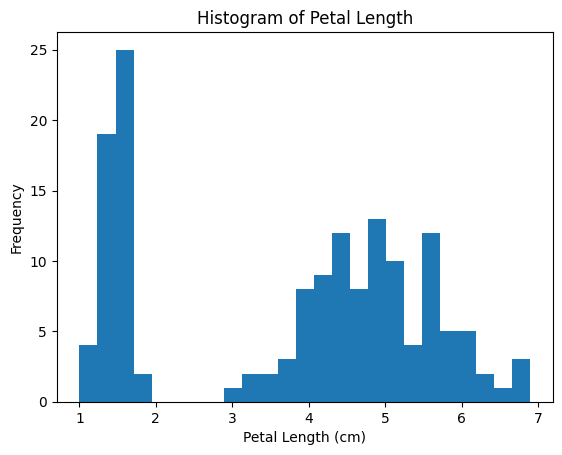

In [43]:
plt.hist(data.petal_length, bins=25);
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.title('Histogram of Petal Length');

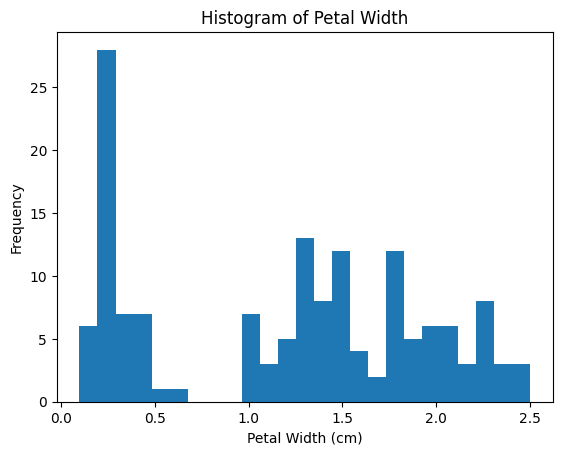

In [45]:
plt.hist(data.petal_width, bins=25);
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.title('Histogram of Petal Width');

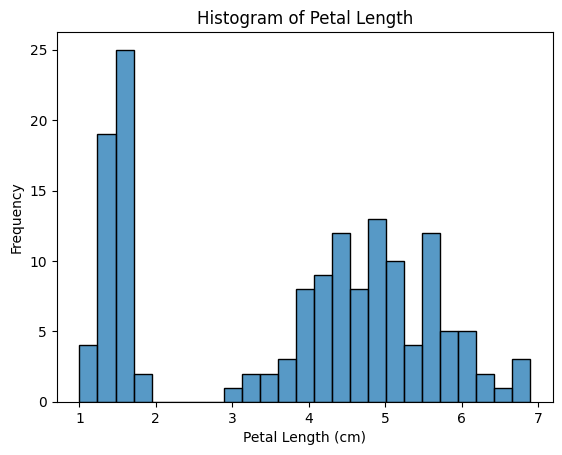

In [44]:
# Alternatively we can use seaborn
import seaborn as sns

sns.histplot(data.petal_length, bins=25)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.title('Histogram of Petal Length');

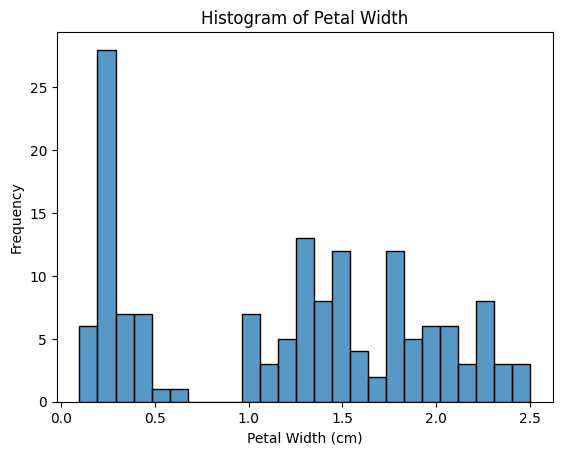

In [46]:
sns.histplot(data.petal_width, bins=25)
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.title('Histogram of Petal Width');

In [ ]:
### BEGIN SOLUTION
# Using Matplotlib's plotting functionality
ax = plt.axes()
ax.hist(data.petal_length, bins=25);

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');

In [ ]:
# Alternatively using Pandas plotting functionality
ax = data.petal_length.plot.hist(bins=25)

ax.set(xlabel='Petal Length (cm)',
       ylabel='Frequency',
       title='Distribution of Petal Lengths');
### END SOLUTION

## Question 7

Now create a single plot with histograms for each feature (`petal_width`, `petal_length`, `sepal_width`, `sepal_length`) overlayed. If you have time, next try to create four individual histogram plots in a single figure, where each plot contains one feature.

For some hints on how to do this with Pandas plotting methods, check out the [visualization guide](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) for Pandas.


<Axes: ylabel='Frequency'>

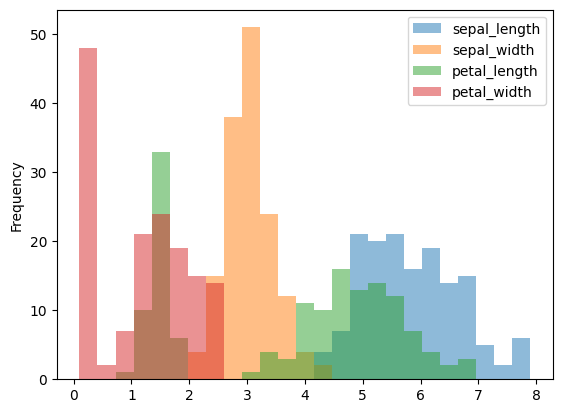

In [47]:
data.plot.hist(bins=25, alpha=0.5)

<Axes: ylabel='Count'>

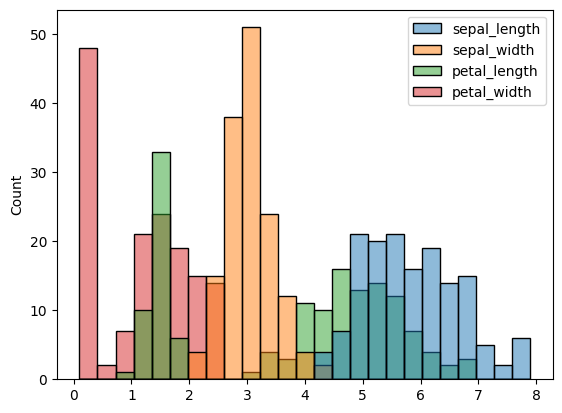

In [48]:
sns.histplot(data, bins=25, alpha=0.5)

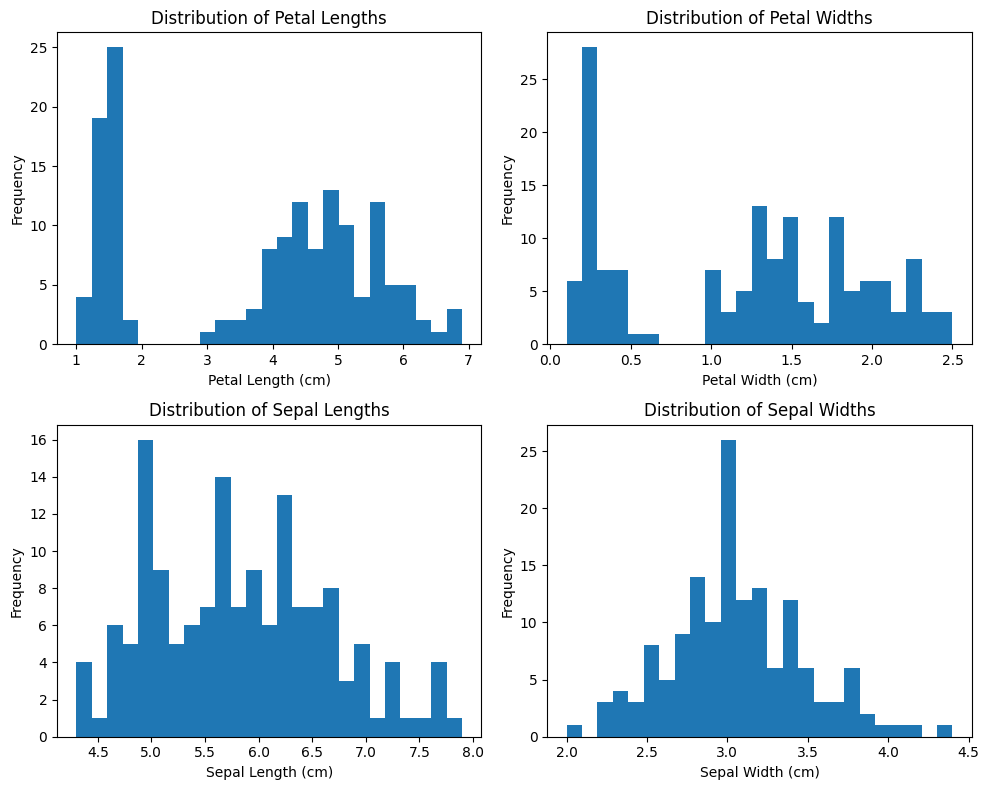

In [49]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Create a 2x2 grid of subplots

# First row
axes[0, 0].hist(data.petal_length, bins=25)
axes[0, 0].set(xlabel='Petal Length (cm)',
               ylabel='Frequency',
               title='Distribution of Petal Lengths')

axes[0, 1].hist(data.petal_width, bins=25)
axes[0, 1].set(xlabel='Petal Width (cm)',
               ylabel='Frequency',
               title='Distribution of Petal Widths')

# Second row
axes[1, 0].hist(data.sepal_length, bins=25)
axes[1, 0].set(xlabel='Sepal Length (cm)',
               ylabel='Frequency',
               title='Distribution of Sepal Lengths')

axes[1, 1].hist(data.sepal_width, bins=25)
axes[1, 1].set(xlabel='Sepal Width (cm)',
               ylabel='Frequency',
               title='Distribution of Sepal Widths')

plt.tight_layout()
plt.show()

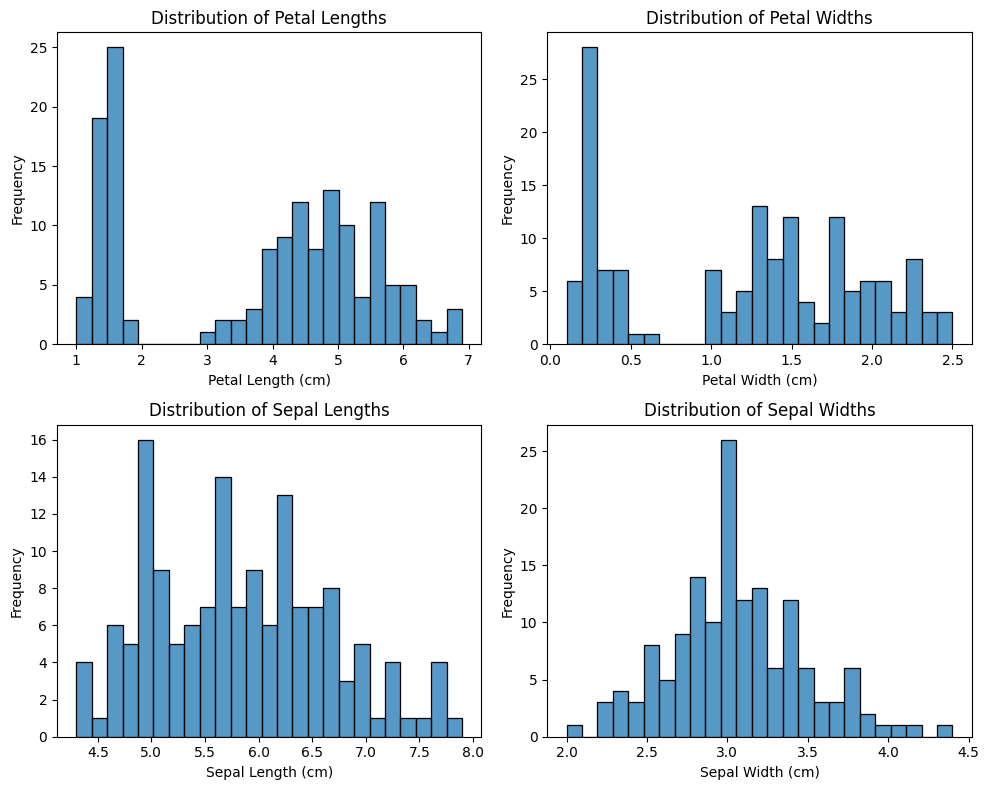

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# First row
sns.histplot(data=data, x='petal_length', bins=25, ax=axes[0, 0], kde=False)
axes[0, 0].set(xlabel='Petal Length (cm)', ylabel='Frequency', title='Distribution of Petal Lengths')

sns.histplot(data=data, x='petal_width', bins=25, ax=axes[0, 1], kde=False)
axes[0, 1].set(xlabel='Petal Width (cm)', ylabel='Frequency', title='Distribution of Petal Widths')

# Second row
sns.histplot(data=data, x='sepal_length', bins=25, ax=axes[1, 0], kde=False)
axes[1, 0].set(xlabel='Sepal Length (cm)', ylabel='Frequency', title='Distribution of Sepal Lengths')

sns.histplot(data=data, x='sepal_width', bins=25, ax=axes[1, 1], kde=False)
axes[1, 1].set(xlabel='Sepal Width (cm)', ylabel='Frequency', title='Distribution of Sepal Widths')

plt.tight_layout()
plt.show()


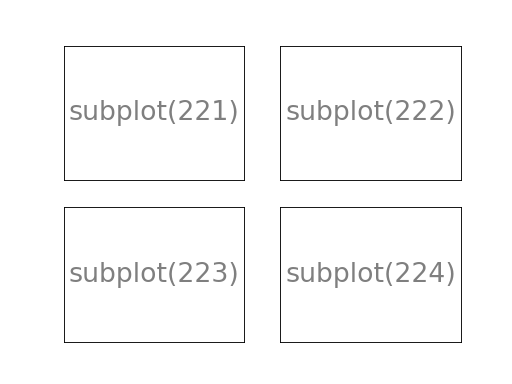

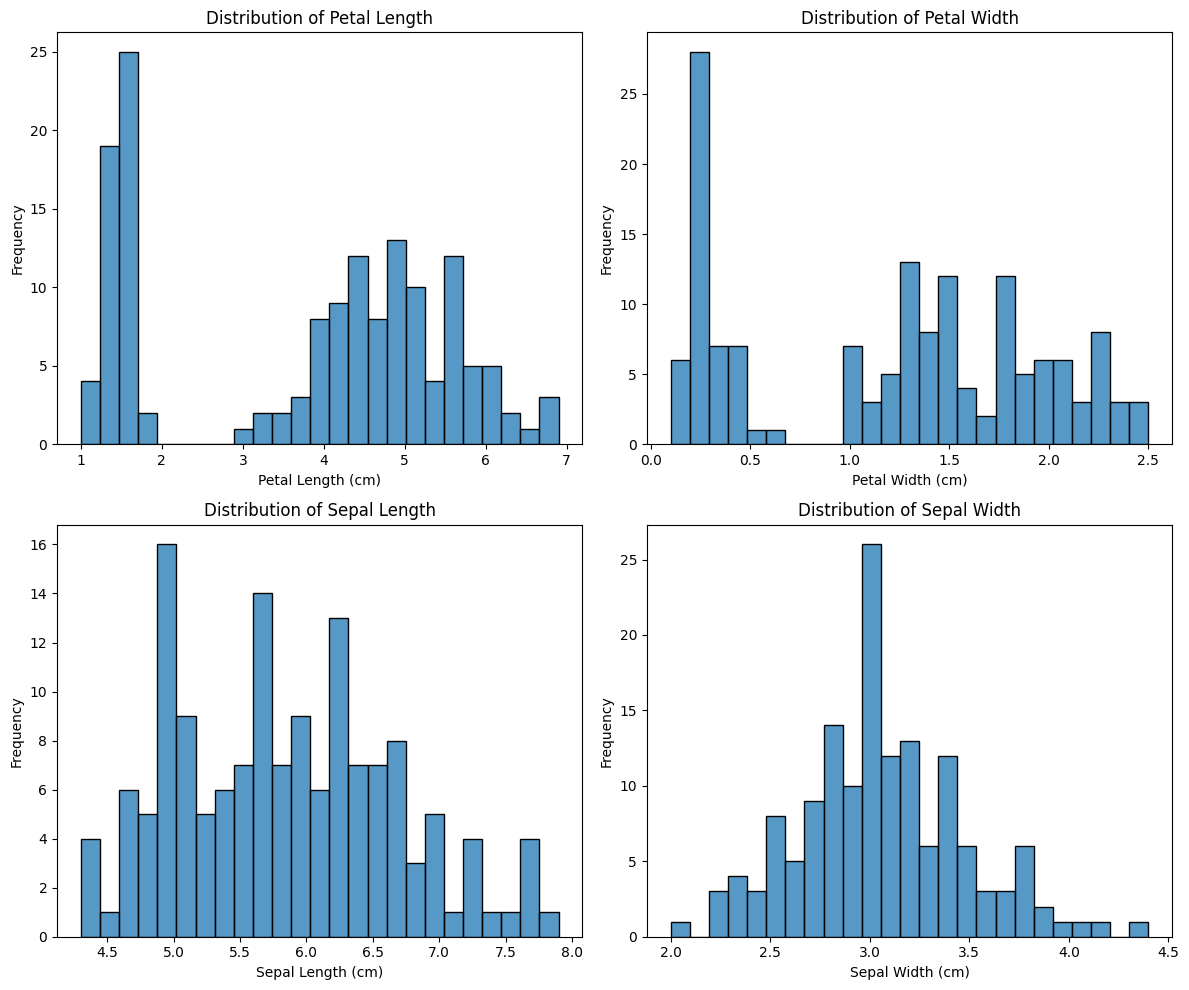

In [53]:
# This structure is particularly preferred by me as it is similar to Matlab style for subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(12, 10))

# Subplot 1
plt.subplot(221)
sns.histplot(data=data, x='petal_length', bins=25, kde=False)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Petal Length')

# Subplot 2
plt.subplot(222)
sns.histplot(data=data, x='petal_width', bins=25, kde=False)
plt.xlabel('Petal Width (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Petal Width')

# Subplot 3
plt.subplot(223)
sns.histplot(data=data, x='sepal_length', bins=25, kde=False)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Length')

# Subplot 4
plt.subplot(224)
sns.histplot(data=data, x='sepal_width', bins=25, kde=False)
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Frequency')
plt.title('Distribution of Sepal Width')

# Adjust layout
plt.tight_layout()
plt.show()


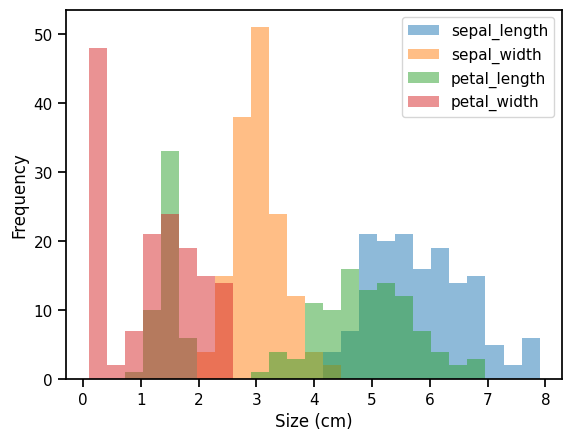

In [54]:
import seaborn as sns
sns.set_context('notebook')
### BEGIN SOLUTION
# This uses the `.plot.hist` method
ax = data.plot.hist(bins=25, alpha=0.5)
ax.set_xlabel('Size (cm)');

In [ ]:
# To create four separate plots, use Pandas `.hist` method
axList = data.hist(bins=25)

# Add some x- and y- labels to first column and last row
for ax in axList.flatten():
    if ax.is_last_row():
        ax.set_xlabel('Size (cm)')

    if ax.is_first_col():
        ax.set_ylabel('Frequency')
### END SOLUTION

## Question 8

Using Pandas, make a boxplot of each petal and sepal measurement. Here is the documentation for [Pandas boxplot method](http://pandas.pydata.org/pandas-docs/version/0.18.1/visualization.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01#visualization-box).


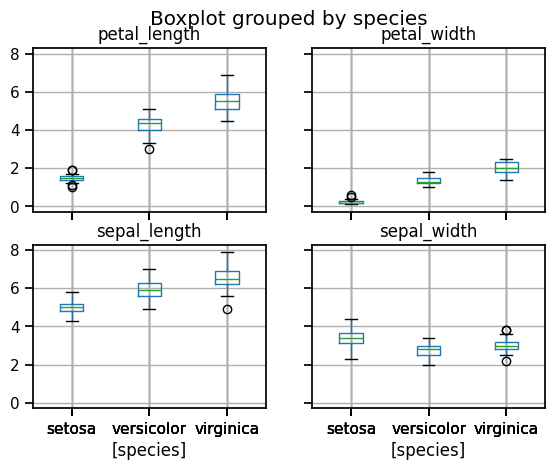

In [55]:
data.boxplot(by='species');

In [ ]:
### BEGIN SOLUTION
# Here we have four separate plots
data.boxplot(by='species');
### END SOLUTION

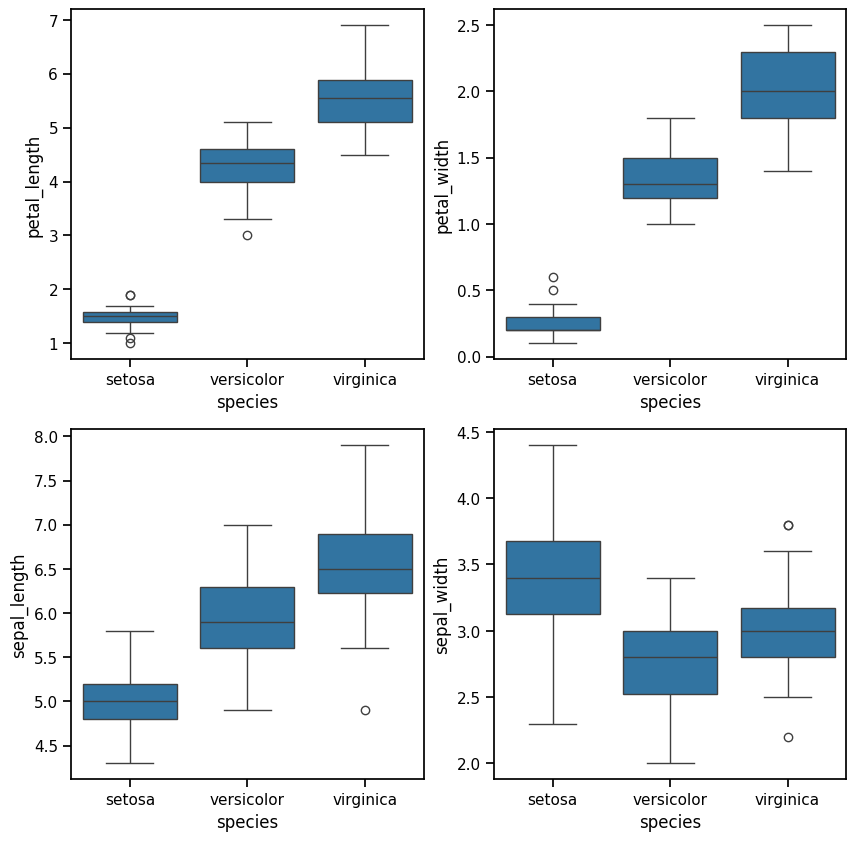

In [61]:
# This structure is particularly preferred by me as it is similar to Matlab style for subplots
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(10, 10))
plt.subplot(221)
sns.boxplot(data=data, x='species', y='petal_length');
plt.subplot(222)
sns.boxplot(data=data, x='species', y='petal_width');
plt.subplot(223)
sns.boxplot(data=data, x='species', y='sepal_length');
plt.subplot(224)
sns.boxplot(data=data, x='species', y='sepal_width');

## Question 9

Now make a single boxplot where the features are separated in the x-axis and species are colored with different hues.

*Hint:* you may want to check the documentation for [Seaborn boxplots](http://seaborn.pydata.org/generated/seaborn.boxplot.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01).

Also note that Seaborn is very picky about data format--for this plot to work, the input dataframe will need to be manipulated so that each row contains a single data point (a species, a measurement type, and the measurement value). Check out Pandas [stack](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.stack.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) method as a starting place.

Here is an example of a data format that will work:

|   | species | measurement  | size |
| - | ------- | ------------ | ---- |
| 0	| setosa  | sepal_length | 5.1  |
| 1	| setosa  | sepal_width  | 3.5  |


In [62]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [63]:
# Reshaping the DataFrame from wide format to long format using melt
reshaped_df = data.melt(id_vars=['species'],  # Keep 'species' as identifier
                      value_vars=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],  # Columns to reshape
                      var_name='measurement',  # Name for the original column names
                      value_name='size')  # New name for the values

### Understanding `pandas.melt` Parameters

Let's break down these parameters for the `pandas.melt` function:

* `id_vars=['species']`:
    * This specifies the column(s) that will **not** be "unpivoted" or "melted". They remain as identifier variables.
    * In this case, the `species` column will be kept as is, identifying each row's group.

* `value_vars=['sepal_length', 'sepal_width', 'petal_length', 'petal_width']`:
    * These are the columns whose values you want to consolidate into fewer columns.
    * We are telling pandas to take the data currently spread across these four columns (`sepal_length`, `sepal_width`, `petal_length`, `petal_width`) and reshape it.

* `var_name='measurement'`:
    * This sets the name for the **new** column that will contain the *names* of the original columns specified in `value_vars`.
    * After melting, there will be a new column called `measurement`, and its values will be things like `'sepal_length'`, `'sepal_width'`, etc.

* `value_name='size'`:
    * This sets the name for the **new** column that will contain the *values* originally found in the `value_vars` columns.
    * After melting, there will be a new column called `size`, holding the corresponding numeric measurements (e.g., the actual length or width value).

In [64]:
reshaped_df.head()

,species,measurement,size
0,setosa,sepal_length,5.1
1,setosa,sepal_length,4.9
2,setosa,sepal_length,4.7
3,setosa,sepal_length,4.6
4,setosa,sepal_length,5.0


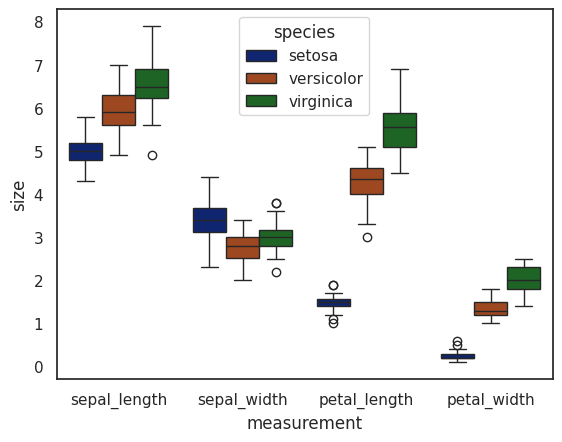

In [65]:
# Now we can use seaborn and hue by the type of species
sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')
# The previous lines are optional
sns.boxplot(x='measurement', y='size', hue='species', data=reshaped_df);

In [ ]:
### BEGIN SOLUTION
# First we have to reshape the data so there is
# only a single measurement in each column

plot_data = (data
             .set_index('species')
             .stack()
             .to_frame()
             .reset_index()
             .rename(columns={0:'size', 'level_1':'measurement'})
            )

plot_data.head()
### END SOLUTION

In [ ]:
### BEGIN SOLUTION
# Now plot the dataframe from above using Seaborn

sns.set_style('white')
sns.set_context('notebook')
sns.set_palette('dark')

f = plt.figure(figsize=(6,4))
sns.boxplot(x='measurement', y='size',
            hue='species', data=plot_data);
### END SOLUTION

## Question 10

Make a [pairplot](http://seaborn.pydata.org/generated/seaborn.pairplot.html?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0232ENSkillsNetwork837-2023-01-01) with Seaborn to examine the correlation between each of the measurements.

*Hint:* this plot may look complicated, but it is actually only a single line of code. This is the power of Seaborn and dataframe-aware plotting! See the lecture notes for reference.


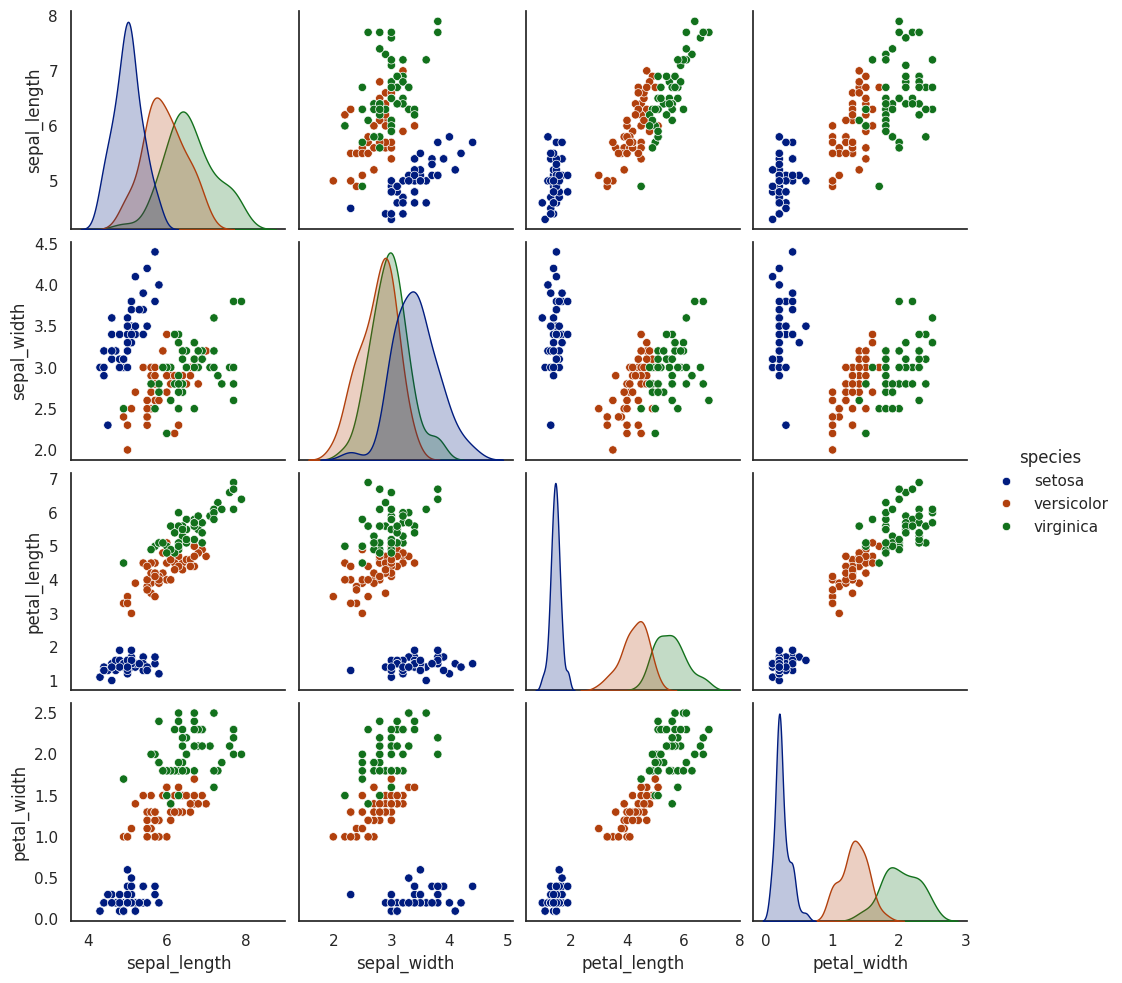

In [66]:
sns.pairplot(data, hue='species');

In [ ]:
### BEGIN SOLUTION
sns.set_context('talk')
sns.pairplot(data, hue='species');
### END SOLUTION

---
### Machine Learning Foundation (C) 2020 IBM Corporation


In [76]:
import pandas as pd
import numpy as np

# Sample product sales data
products = [f'Product {chr(65 + i)}' for i in range(5)]  # Product A to Product T
np.random.seed(0)

df_sales = pd.DataFrame({
    'Product': products,
    'January': np.random.randint(100, 500, size=5),
    'February': np.random.randint(100, 500, size=5),
    'March': np.random.randint(100, 500, size=5)
})

print(df_sales.head())


     Product  January  February  March
0  Product A      272       351    377
1  Product B      147       295    342
2  Product C      217       459    392
3  Product D      292       109    187
4  Product E      423       311    170


In [78]:
# Melt to long format
df_long = df_sales.melt(id_vars='Product',
                        value_vars=['January', 'February', 'March'],
                        var_name='Month',
                        value_name='Sales')

print(df_long.head(6))


     Product     Month  Sales
0  Product A   January    272
1  Product B   January    147
2  Product C   January    217
3  Product D   January    292
4  Product E   January    423
5  Product A  February    351
